In [27]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm


In [28]:
df = pd.read_csv("loan.csv")
df.head()
print(df.shape)

(614, 10)


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
dtypes: float64(3), int64(1), str(6)
memory usage: 64.5 KB


In [30]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0


In [31]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
dtype: int64

In [32]:
df['loan_Amount_log'] = np.log(df['LoanAmount'])

<Axes: >

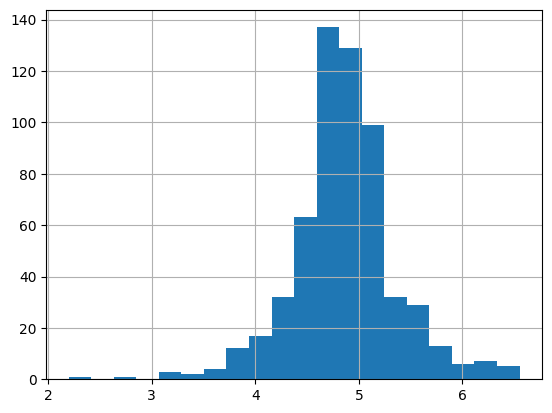

In [33]:
df['loan_Amount_log'].hist(bins = 20)

In [34]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
loan_Amount_log      22
dtype: int64

In [36]:
df['TotalIncome'] = df['ApplicantIncome']+ df['CoapplicantIncome']

In [37]:
df['TotalIncome_log'] = np.log(df['TotalIncome'])

<Axes: >

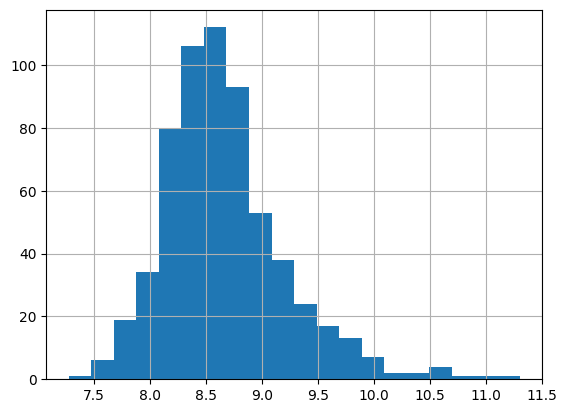

In [38]:
df['TotalIncome_log'].hist(bins = 20)

In [52]:
df['Gender'].fillna(df['Gender'].mode()[0] , inplace  = True)
df['Dependents'].fillna(df['Dependents'].mode()[0] , inplace  = True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0] , inplace  = True)
df['Married'].fillna(df['Married'].mode()[0] , inplace  = True)






C:\Users\Dilan\AppData\Local\Temp\ipykernel_21928\3308186228.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0] , inplace  = True)
C:\Users\Dilan\AppData\Local\Temp\ipykernel_21928\3308186228.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

0       No
1      Yes
2      Yes
3      Yes
4       No
      ... 
609     No
610    Yes
611    Yes
612    Yes
613     No
Name: Married, Length: 614, dtype: str

In [47]:
df.LoanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())

In [49]:
df.loan_Amount_log = df.loan_Amount_log.fillna(df.loan_Amount_log.mean())

In [50]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0] , inplace = True)

C:\Users\Dilan\AppData\Local\Temp\ipykernel_21928\31119069.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0] , inplace = True)


0      360.0
1      360.0
2      360.0
3      360.0
4      360.0
       ...  
609    360.0
610    180.0
611    360.0
612    360.0
613    360.0
Name: Loan_Amount_Term, Length: 614, dtype: float64

In [53]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
loan_Amount_log       0
TotalIncome           0
TotalIncome_log       0
dtype: int64

In [ ]:
df.fillna({'Gender'} , inplace=True)

C:\Users\Dilan\AppData\Local\Temp\ipykernel_21928\1478626379.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0] , inplace  = True)


0        Male
1        Male
2        Male
3        Male
4        Male
        ...  
609    Female
610      Male
611      Male
612      Male
613    Female
Name: Gender, Length: 614, dtype: str